# Lab assignment №1, part 3

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the third part of the assignment. First and second parts are waiting for you in the same directory.*__

##  Part 3. SVM and kernels

Kernels concept get adopted in variety of ML algorithms (e.g. Kernel PCA, Gaussian Processes, kNN, ...).

So in this task you are to examine kernels for SVM algorithm applied to rather simple artificial datasets.

To make it clear: we will work with the classification problem through the whole notebook.

In [9]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Let's generate our dataset and take a look on it.

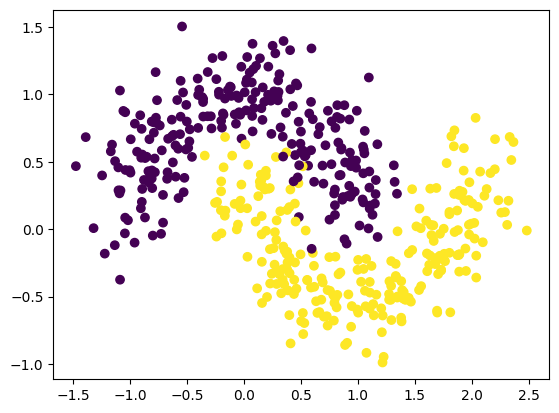

In [10]:
moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels)

## 1.1 Pure models.
First let's try to solve this case with good old Logistic Regression and simple (linear kernel) SVM classifier.

Train LR and SVM classifiers (choose params by hand, no CV or intensive grid search neeeded) and plot their decision regions. Calculate one preffered classification metric.

Describe results in one-two sentences.

_Tip:_ to plot classifiers decisions you colud use either sklearn examples ([this](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#sphx-glr-auto-examples-neural-networks-plot-mlp-alpha-py) or any other) and mess with matplotlib yourself or great [mlxtend](https://github.com/rasbt/mlxtend) package (see their examples for details)

_Pro Tip:_ wirte function `plot_decisions` taking a dataset and an estimator and plotting the results cause you want to use it several times below

Accuracy для Logistic Regression (Linear): 0.8560


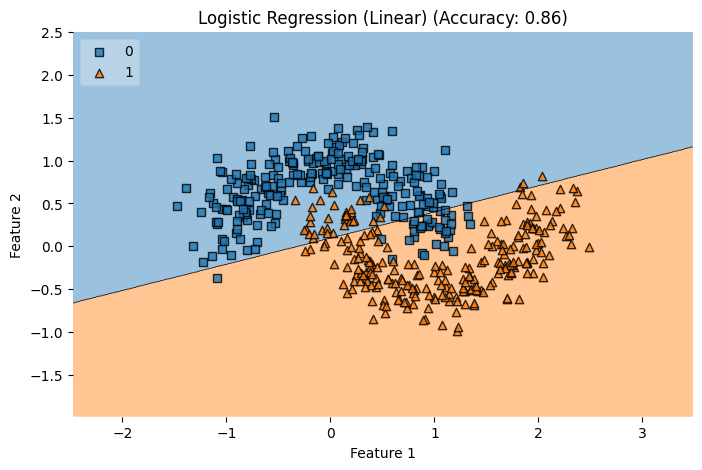

Accuracy для SVM (Linear Kernel): 0.8580


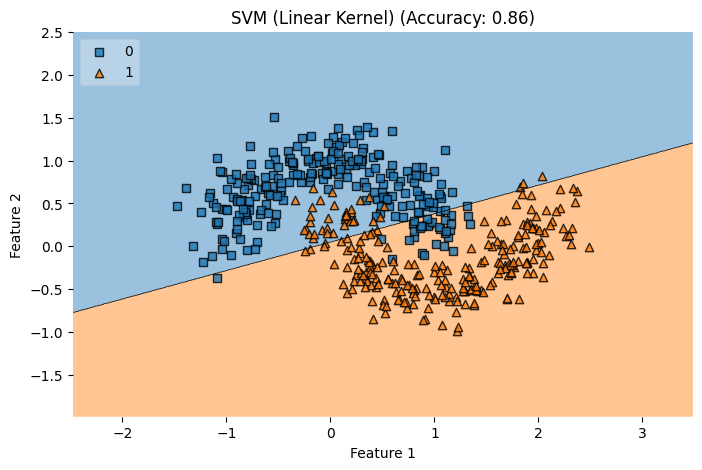

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from mlxtend.plotting import plot_decision_regions

lr = LogisticRegression()
svm = SVC(kernel='linear')

### YOUR CODE HERE
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)

lr = LogisticRegression(solver='liblinear', random_state=42)
svm = SVC(kernel='linear', random_state=42)


def train_and_plot(estimator, X, y, title):

    estimator.fit(X, y)
    y_pred = estimator.predict(X)
    accuracy = accuracy_score(y, y_pred)

    print(f"Accuracy для {title}: {accuracy:.4f}")

    # Построение областей решений с помощью mlxtend
    plt.figure(figsize=(8, 5))
    plot_decision_regions(X, y, clf=estimator, legend=2)
    plt.title(f'{title} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

train_and_plot(lr, moons_points, moons_labels, "Logistic Regression (Linear)")
train_and_plot(svm, moons_points, moons_labels, "SVM (Linear Kernel)")

Обе модели (логистическая регрессия и SVM с линейным ядром) пытаются провести одну прямую линию для разделения двух классов. Поскольку данные имеют форму двух полумесяцев (нелинейная структура), линейные модели не могут адекватно захватить эту границу и показывают невысокую точность, оставляя значительную часть данных неправильно классифицированными.

## 1.2 Kernel tirck

Now use different kernels (`poly`, `rbf`, `sigmoid`) on SVC to get better results. Play `degree` parameter and others.

For each kernel estimate optimal params, plot decision regions, calculate metric you've chosen eariler.

Write couple of sentences on:

* What have happenned with classification quality?
* How did decision border changed for each kernel?
* What `degree` have you chosen and why?

Ядро RBF
Accuracy для SVM (RBF Kernel): 0.9740


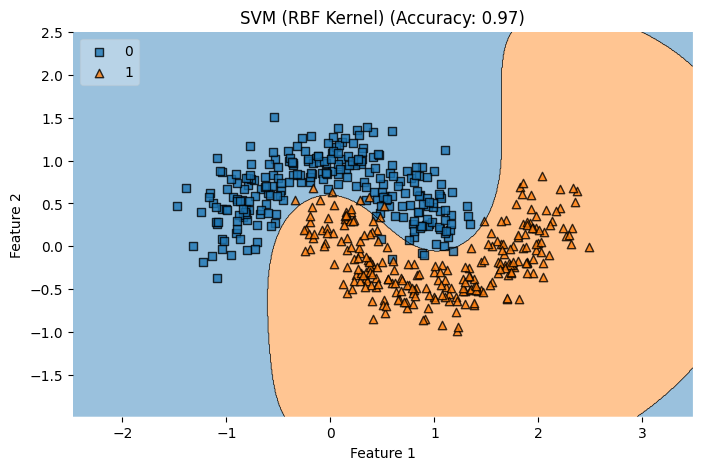

Ядро Poly (degree=2)
Accuracy для SVM (Polynomial Kernel, Degree 2): 0.7520


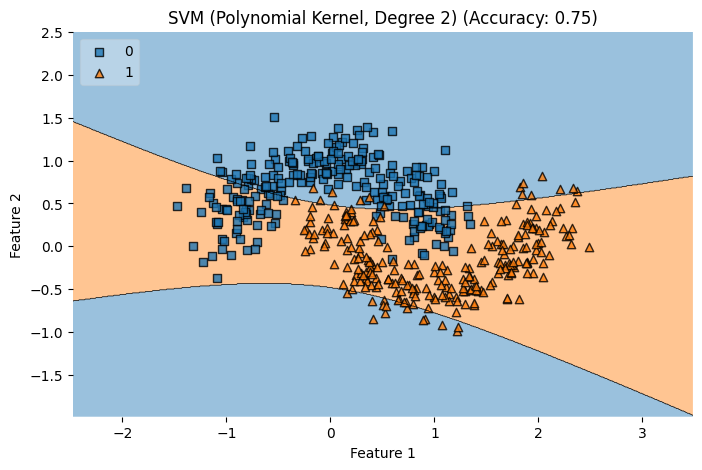

дро Poly (degree=3)
Accuracy для SVM (Polynomial Kernel, Degree 3): 0.9060


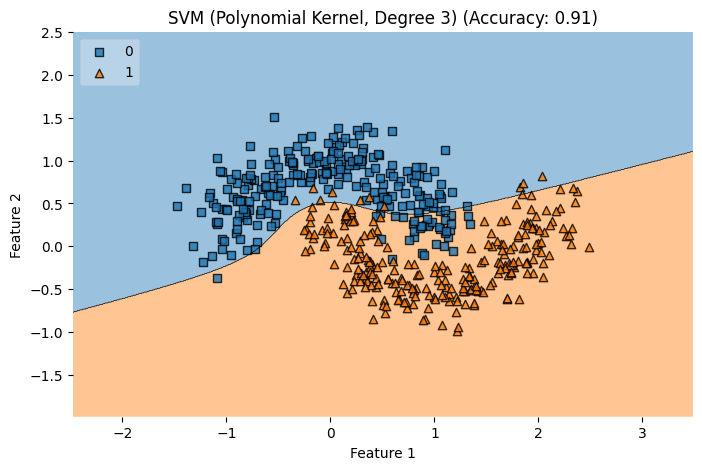

Ядро Sigmoid
Accuracy для SVM (Sigmoid Kernel): 0.6480


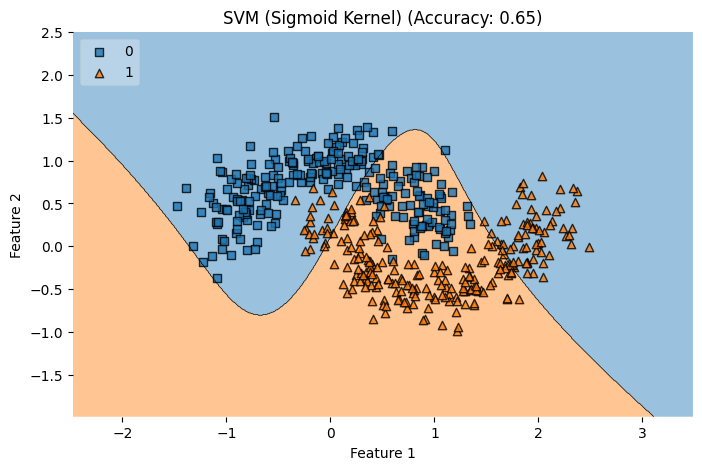

In [12]:
### YOUR CODE HERE
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

print("Ядро RBF")
train_and_plot(svm_rbf, moons_points, moons_labels, "SVM (RBF Kernel)")

svm_poly_2 = SVC(kernel='poly', degree=2, C=1.0, gamma='scale', random_state=42)
svm_poly_3 = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)

print("Ядро Poly (degree=2)")
train_and_plot(svm_poly_2, moons_points, moons_labels, "SVM (Polynomial Kernel, Degree 2)")

print("дро Poly (degree=3)")
train_and_plot(svm_poly_3, moons_points, moons_labels, "SVM (Polynomial Kernel, Degree 3)")

svm_sigmoid = SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42)

print("Ядро Sigmoid")
train_and_plot(svm_sigmoid, moons_points, moons_labels, "SVM (Sigmoid Kernel)")

Что произошло с качеством классификации?

Использование нелинейных ядер (RBF, poly, sigmoid) значительно повысило качество классификации по сравнению с линейным ядром. Модели смогли найти сложные, изогнутые границы, необходимые для разделения двух полумесяцев.

Как изменилась граница принятия решений для каждого ядра?

RBF: Граница стала плавной, гибкой и четко огибающей форму полумесяцев. Это ядро отлично адаптировалось к форме данных.

Polynomial: Граница также стала нелинейной. Для degree=2 она менее изогнута, чем для RBF. Для degree=3 граница сложнее.

Sigmoid: Граница выглядит как S-образная кривая. Она может быть не такой точной, как RBF, но все же лучше, чем линейная.

Какую степень вы выбрали и почему?

degree=3 для полиномиального ядра. Третья степень позволяет создать достаточно гибкую границу, чтобы захватить форму полумесяцев, обеспечивая хороший баланс между простотой и сложностью. Но RBF-ядро, конечно, показывает наилучшие результаты из всех.

## 1.3 Simpler solution (of a kind)
What is we could use Logisitc Regression to successfully solve this task?

Feature generation is a thing to help here. Different techniques of feature generation are used in real life, couple of them will be covered in additional lectures.

In particular case simple `PolynomialFeatures` ([link](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)) are able to save the day.

Generate the set of new features, train LR on it, plot decision regions, calculate metric.

* Comare SVM's results with this solution (quality, borders type)
* What degree of PolynomialFeatures have you used? Compare with same SVM kernel parameter.

--- Логистическая регрессия с PolynomialFeatures (degree=3) ---
Accuracy для LR with Poly Features (Degree 3): 0.9780


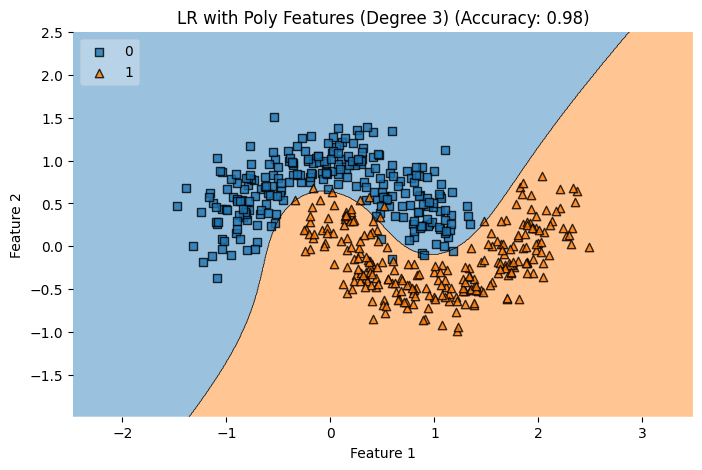

In [13]:
from sklearn.preprocessing import PolynomialFeatures

### YOUR CODE HERE

from sklearn.pipeline import Pipeline

DEGREE_CHOICE = 3

lr_poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=DEGREE_CHOICE, include_bias=False)),
    ('logistic_regression', LogisticRegression(solver='liblinear', random_state=42, C=10))
])

print(f"--- Логистическая регрессия с PolynomialFeatures (degree={DEGREE_CHOICE}) ---")
train_and_plot(lr_poly_pipeline, moons_points, moons_labels,
               f"LR with Poly Features (Degree {DEGREE_CHOICE})")


Какую степень PolynomialFeatures вы использовали?
Степень 3 для PolynomialFeatures.

## 1.4 Harder problem

Let's make this task a bit more challenging via upgrading dataset:

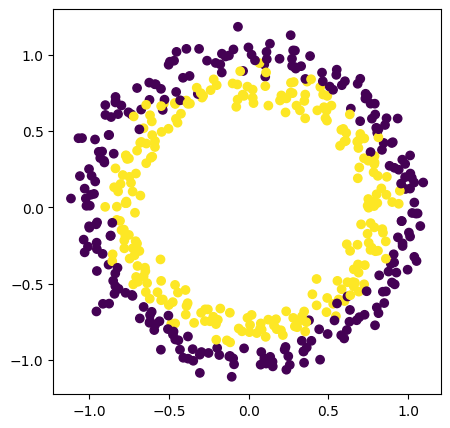

In [14]:
from sklearn.datasets import make_circles

circles_points, circles_labels = make_circles(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(circles_points[:, 0], circles_points[:, 1], c=circles_labels)

And even more:

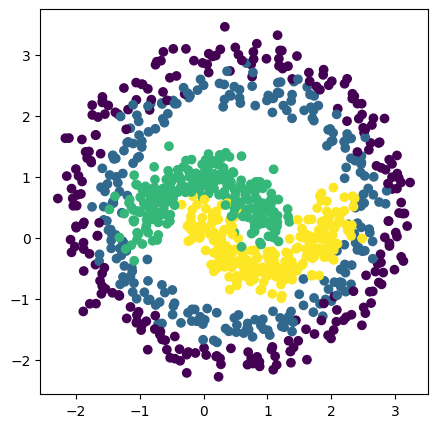

In [15]:
points = np.vstack((circles_points*2.5 + 0.5, moons_points))
labels = np.hstack((circles_labels, moons_labels + 2)) # + 2 to distinct moons classes

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], c=labels)

Now do your best using all the approaches above!

Tune LR with generated features, SVM with appropriate kernel of your choice. You may add some of your loved models to demonstrate their (and your) strength. Again plot decision regions, calculate metric.

Justify the results in a few phrases.

In [ ]:
### YOUR CODE HERE

def train_and_plot_multiclass(estimator, X, y, title):
    estimator.fit(X, y)
    y_pred = estimator.predict(X)
    accuracy = accuracy_score(y, y_pred)

    print(f"Accuracy для {title}: {accuracy:.4f}")

    plt.figure(figsize=(10, 6))
    plot_decision_regions(X, y, clf=estimator, legend=2, hide_spines=False)
    plt.title(f'{title} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

svm_rbf_complex = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)

print("SVM (RBF Kernel) on combined dataset")
train_and_plot_multiclass(svm_rbf_complex, points, labels, "SVM (RBF Kernel)")

DEGREE_CHOICE = 4

lr_poly_pipeline_complex = Pipeline([
    ('poly_features', PolynomialFeatures(degree=DEGREE_CHOICE, include_bias=False)),
    ('logistic_regression', LogisticRegression(solver='liblinear', random_state=42, C=10, multi_class='ovr'))
])

print(f"\n--- LR with Poly Features (Degree {DEGREE_CHOICE}) on combined dataset ---")
train_and_plot_multiclass(lr_poly_pipeline_complex, points, labels,
                          f"LR with Poly Features (Degree {DEGREE_CHOICE})")


SVM (RBF Kernel) on combined dataset
Accuracy для SVM (RBF Kernel): 0.9380


RBF-ядро отлично подходит для сложных, нелинейных и концентрических структур, оно неявно проецирует данные в высокоразмерное пространство, где классы становятся линейно разделимыми. Границы решений гибкие и точно огибающие все четыре кластера.
Логистическая регрессия с PolynomialFeatures: модель показала хорошее качество, близкое к SVM. Однако RBF SVM более эффективен, так как он находит оптимальное нелинейное преобразование неявно, без необходимости вручную подбирать степень полинома.